# Hazard: Hail in Europe


Author: Timo Schmid 
Date: March 2026

This notebook gives a quick tour of the hail hazard data on the climada data API and its usage for impact modelling

## Data overview and usage

The climada data API contains hail hazard data, based on high-resolution climate simulations with the COSMO model and the HAILCAST hail diagnostic, conducted within the [scClim](https://scclim.ethz.ch) research project. 
The data has been spatially perturbed to create a small probabilistic event set of 330-year duration, as described in detail in [Schmid et al. (2026)](https://doi.org/10.1016/j.cliser.2025.100630)


In [1]:
# Import packages
import pandas as pd
import numpy as np

from climada.util.api_client import Client
from climada.entity import ImpactFuncSet, ImpactFunc
from climada.engine import ImpactCalc

In [2]:
# Parameter definitions
country = "FRA"

In [3]:
# Function definitions
def get_emanuel_vals(intensity, v_thresh=20, v_half=60, scale=1, power=3):
    """Get the sigmoidal impact function values for a given intensity array.
    This version of an asymetric sigmoidal function was first used for risk
    modelling by Kerry Emanuel, 2011: https://doi.org/10.1175/WCAS-D-11-00007.1"""

    # Check whether the input parameters are valid
    if v_half <= v_thresh:
        raise ValueError("Shape parameters out of range: v_half <= v_thresh.")
    if v_thresh < 0 or v_half < 0:
        raise ValueError("Negative shape parameter.")
    if scale > 1 or scale <= 0:
        raise ValueError("Scale parameter out of range.")

    # Calculate the impact function values
    v_temp = (intensity - v_thresh) / (v_half - v_thresh)
    v_temp[v_temp < 0] = 0
    v_temp = v_temp**power / (1 + v_temp**power)
    v_temp *= scale
    return v_temp


# define simple quadratic fit function (not full polynomial)
def x4_func(x, a, b):
    return a * x**4 + b

In [4]:
# Get an overview of the properties of the 'hail' data type on the climada API
client = Client()
data_types = client.list_data_type_infos()
dtf = pd.DataFrame(data_types)


# Select the row with data_type 'hail' and print the 'properties' column
hail_properties = dtf[dtf["data_type"] == "hail"].iloc[0]["properties"]
for row in hail_properties:
    print(row)

{'property': 'data_source', 'mandatory': True, 'description': 'radar (Radar-based daily hail hazard data), model (330-year probabilistice event set)'}
{'property': 'radar_variable', 'mandatory': False, 'description': 'MESHS (Maximum Expected Severe Hail Size), POH (Probability Of Hail)'}
{'property': 'climate_scenario', 'mandatory': False, 'description': 'REF (Reference period (2011-2021)), PGW (degree PGW scenario)'}
{'property': 'country_iso3alpha', 'mandatory': False, 'description': 'ISO3 alpha code for country'}
{'property': 'res_km', 'mandatory': False, 'description': 'spatial resolution in kilometers'}


## Hazard

In [5]:
# Load the hazard data
# When first executed, this may take a few minutes depending on internet speed,
# thereafter data is locally stored

haz_ref = client.get_hazard(
    "hail",
    properties={
        "data_source": "model",
        "climate_scenario": "REF",
        "country_iso3alpha": country,
    },
)

haz_fut = client.get_hazard(
    "hail",
    properties={
        "data_source": "model",
        "climate_scenario": "PGW",
        "country_iso3alpha": country,
    },
)

2026-05-21 15:52:25,795 - climada.hazard.io - INFO - Reading /Users/vgebhart/climada/data/hazard/hail/hail_FRA_REF/v2/hail_FRA_ref.h5
2026-05-21 15:52:27,175 - climada.hazard.io - INFO - Reading /Users/vgebhart/climada/data/hazard/hail/hail_FRA_PGW/v2/hail_FRA_PGW.h5


<GeoAxes: title={'center': 'HL max intensity at each point'}>

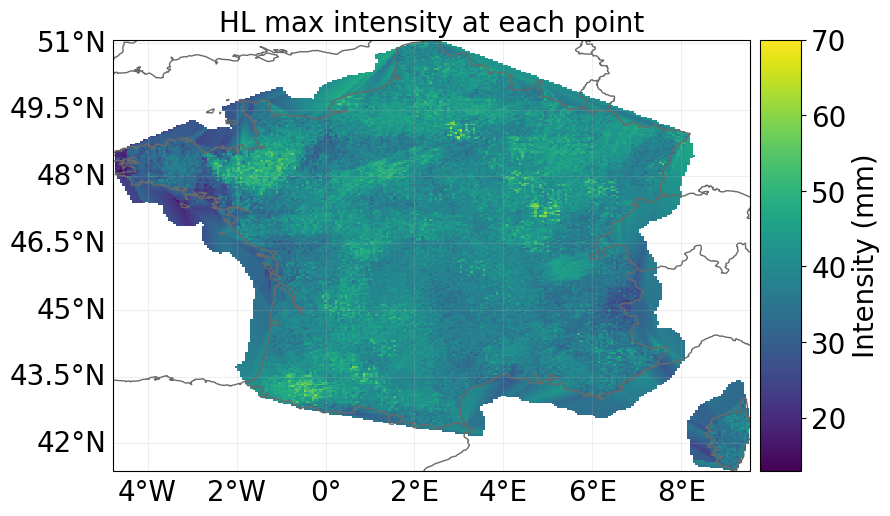

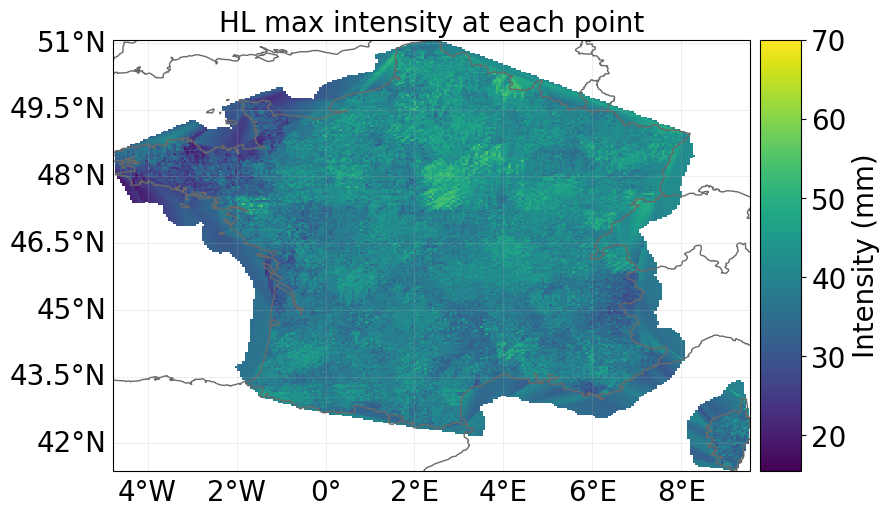

In [6]:
haz_ref.plot_intensity(0, vmax=70)
haz_fut.plot_intensity(0, vmax=70)

<GeoAxes: title={'center': 'Event ID 64977: ev_210621_ens01'}>

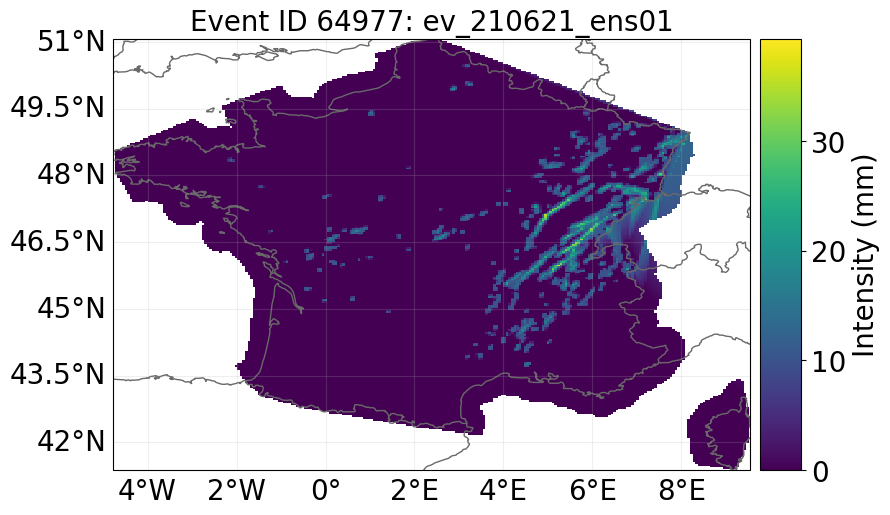

In [7]:
# Plot one event on June 21 2021
ev_id = haz_ref.event_id[np.array(haz_ref.event_name) == "ev_210621_ens01"][0]
haz_ref.plot_intensity(event=ev_id)

## Vulnerability

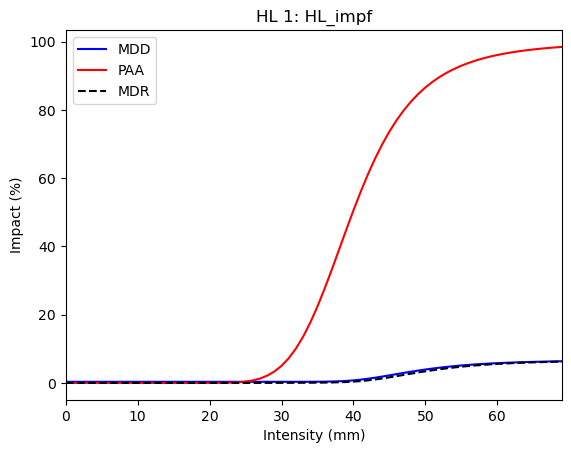

In [8]:
# Set vulnerability functions as described in Schmid et al (2026); Table B.1

params_PAA = {"v_thresh": 17.8, "v_half": 39.9, "scale": 1, "power": 4.95}
params_MDD = {"a": 0.064, "b": 3.33e-3}

# initialize hail impact function
impf = ImpactFunc(
    haz_type="HL",
    id=1,
    intensity=np.arange(0, 70, 1),
    intensity_unit="mm",
    name="HL_impf",
)
# get PAA values (sigmoidal function)
impf.paa = get_emanuel_vals(impf.intensity, **params_PAA)

# get MDD function (depending on PAA values, not directly on intensity)
impf.mdd = x4_func(impf.paa, **params_MDD)
impf.plot()
impfset = ImpactFuncSet([impf])

## Exposure

In an ideal case, one has building-level data and can replicate the scaling in Schmid et al (2026), section B.1.

When using the LitPop exposure data available from the climada data API, this effect can be approximated by using the spatial distribution of the population rather than nightlight, which is less concentrated in urban areas.
For more details on LitPop, see the [corresponding tutorial](https://github.com/CLIMADA-project/climada_python/blob/main/doc/user-guide/climada_entity_LitPop.ipynb). 
Importantly, when using the LitPop data from the data API, choosing different exponents yields different target outputs.

Exponents (0,1) automatically yield data with fin_mode= "population", while exponents (1,1) or (3,0) automatically yield data with fin_mode "pc" (produced capital).

2026-05-21 15:52:46,724 - climada.entity.exposures.base - INFO - Reading /Users/vgebhart/climada/data/exposures/litpop/LitPop_pop_150arcsec_FRA/v3/LitPop_pop_150arcsec_FRA.hdf5
2026-05-21 15:52:48,294 - climada.entity.exposures.base - INFO - Reading /Users/vgebhart/climada/data/exposures/litpop/LitPop_150arcsec_FRA/v3/LitPop_150arcsec_FRA.hdf5
2026-05-21 15:52:48,528 - climada.util.coordinates - INFO - Raster from resolution 0.041666659999999744 to 0.041666659999999744.


/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


<GeoAxes: >

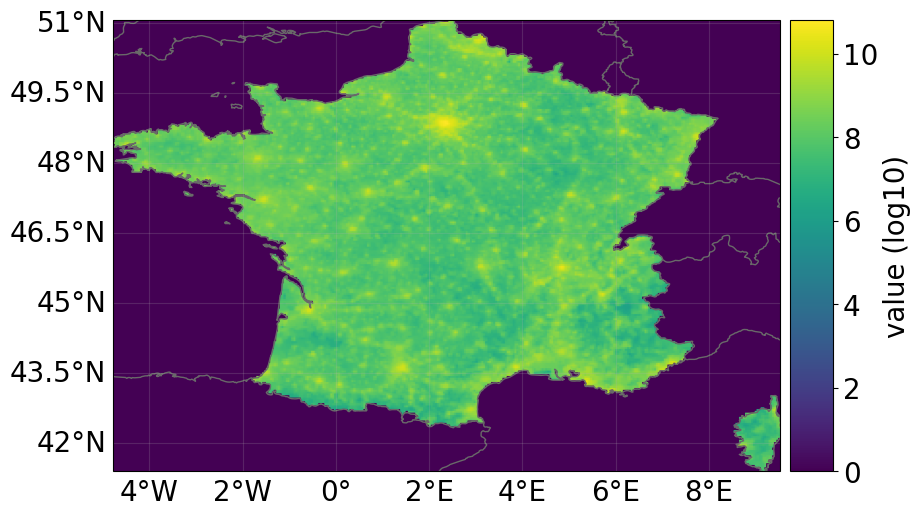

In [9]:
# Load exposure data.

# Load population exposure
exp_population = client.get_litpop(country=country, exponents=(0, 1))
# Load produced capital exposure (corresponding to the total building values)
exp_pc = client.get_litpop(country=country, exponents=(1, 1))

# Use the spatial distribution of the population-based data, but the total value
# of the produced capital (as described above)
exp_litpop_gdf = exp_population.gdf.copy()
exp_litpop_gdf["value"] = (
    exp_population.gdf["value"]
    / exp_population.gdf["value"].sum()
    * exp_pc.gdf["value"].sum()
)
exp_litpop = exp_pc
exp_litpop.set_gdf(exp_litpop_gdf)


# Prepare exposure data for impact calculation and filter if necessary
exp_litpop.gdf.rename(columns={"impf_": "impf_HL"}, inplace=True)
if country == "FRA":
    # filter only mainland France (within coordinate bbox)
    exp_gdf = exp_litpop.gdf[
        (exp_litpop.gdf.geometry.x > -5)
        & (exp_litpop.gdf.geometry.x < 10)
        & (exp_litpop.gdf.geometry.y > 40)
        & (exp_litpop.gdf.geometry.y < 52)
    ]
    exp_litpop.set_gdf(exp_gdf)

exp_litpop.plot_raster()

In [10]:
# impact calculation
exp_litpop.assign_centroids(haz_ref, threshold=0.05)
imp_ref = ImpactCalc(exp_litpop, impfset, haz_ref).impact(
    save_mat=True, assign_centroids=False
)
exp_litpop.assign_centroids(haz_fut, threshold=0.05)
imp_fut = ImpactCalc(exp_litpop, impfset, haz_fut).impact(
    save_mat=True, assign_centroids=False
)

2026-05-21 15:52:51,445 - climada.entity.exposures.base - INFO - Matching 37062 exposures with 110540 centroids.
2026-05-21 15:52:51,525 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.05 degree
2026-05-21 15:52:51,795 - climada.engine.impact_calc - INFO - Calculating impact for 37062 assets (>0) and 68975 events.
2026-05-21 15:52:54,336 - climada.entity.exposures.base - INFO - Existing centroids will be overwritten for HL
2026-05-21 15:52:54,336 - climada.entity.exposures.base - INFO - Matching 37062 exposures with 110540 centroids.
2026-05-21 15:52:54,413 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 0.05 degree
2026-05-21 15:52:54,624 - climada.engine.impact_calc - INFO - Calculating impact for 37062 assets (>0) and 63550 events.


2026-05-21 15:52:56,661 - climada.util.coordinates - INFO - Raster from resolution 0.041666659999999744 to 0.041666659999999744.


/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


2026-05-21 15:52:59,506 - climada.util.coordinates - INFO - Raster from resolution 0.041666659999999744 to 0.041666659999999744.


/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


[Text(0.5, 1.0, 'Expected Annual impact: 856 M USD')]

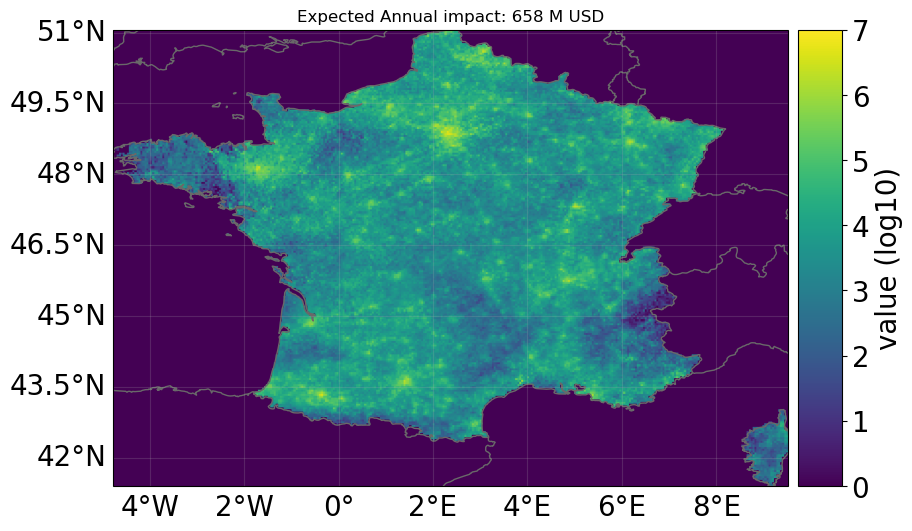

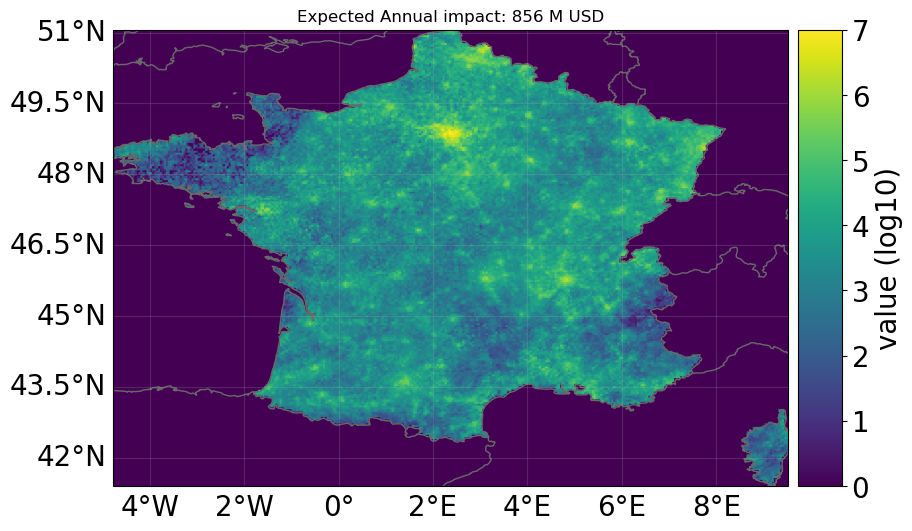

In [11]:
# plot expected annual impact
ax = imp_ref.plot_raster_eai_exposure(vmax=7)  # max 1e7 USD per gridcell
ax.set(title=f"Expected Annual impact: %d M USD" % (imp_ref.aai_agg / 1e6))
# imp_fut.plot_hexbin_eai_exposure(gridsize=80,linewidth=0,pop_name=False)
ax_fut = imp_fut.plot_raster_eai_exposure(vmax=7)
ax_fut.set(title=f"Expected Annual impact: %d M USD" % (imp_fut.aai_agg / 1e6))

[Text(0.5, 1.0, 'Impact of event ev_170622_ens15: 1898 M USD')]

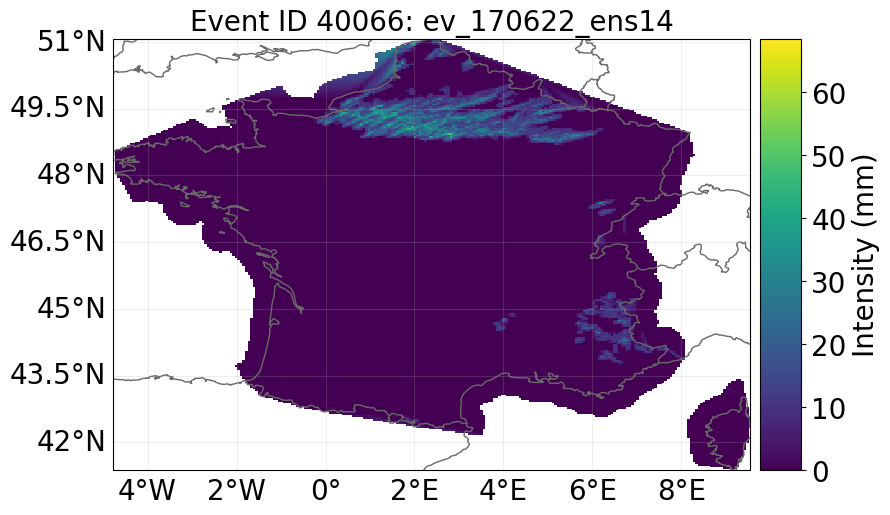

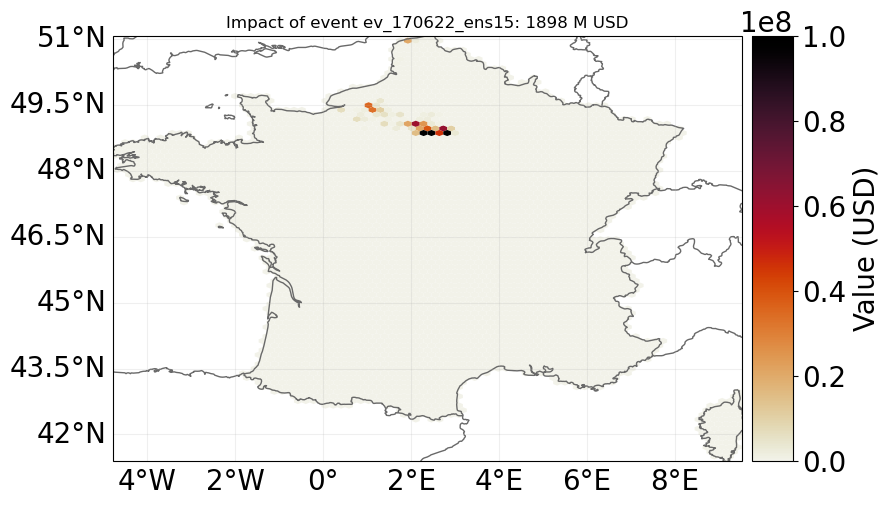

In [12]:
# plot example event (most damaging event in reference scenario)
ev_id_max = imp_ref.event_id[np.argmax(imp_ref.at_event)]
event_loss = imp_ref.at_event.max()

# plot hazard
haz_ref.plot_intensity(event=ev_id_max)

# plot impact
ax = imp_ref.plot_hexbin_impact_exposure(
    event_id=ev_id_max, gridsize=80, linewidth=0, pop_name=False, vmax=1e8
)
ax.set(
    title=f"Impact of event {imp_ref.event_name[ev_id_max]}: %d M USD"
    % (event_loss / 1e6)
)

## Final remarks

Please read [Schmid et al. (2026)](https://doi.org/10.1016/j.cliser.2025.100630) before using results from these hail impact calculations to understand the associated uncertainty. In particular, be aware that the use of LitPop is an approximation of the scaling approach in Schmid et al. (2026), that the vulnerability functions were calibrated over Switzerland, and that results from the generated 330-year event set have increasing uncertainty when considering tail risk events (worst-case scenarios).

Nevertheless, the data allows a fast first overview of overall hail risk in different regions and for custom portfolios based on high-resolution reference period climate simulations and a 3°C global warming scenario as described in detail in [Thurnherr et al. (2025)](https://doi.org/10.22541/au.173809555.59545480/v1)